In [2]:
#Data Loading
import pandas as pd
import numpy as np

# Dataset Twitter #1
df = pd.read_csv('fixedNotClean_all_temp.csv')

# Dataset Twitter #2
df_tw = pd.read_csv('tweets.csv')

#Dataset Facebook
df_fb = pd.read_csv('facebook_posts.csv')

In [3]:
# Data Integration

df = df.rename(columns={'tweet': 'text'})
df_tw= df_tw.rename(columns={'tweet': 'text'})

columns_to_keep = ['sentimenteffective', 'sentimentpet', 'sentimentprocess', 'sentimentrecycle', 'text']
df_fb = df_fb[columns_to_keep]
df_tw = df_tw[columns_to_keep]
df = df[columns_to_keep]

# Combine the DataFrames
combined_df = pd.concat([df_tw, df_fb,df], ignore_index=True)

In [4]:
combined_df = combined_df.drop_duplicates(subset=['text'])
combined_df.to_csv("combined_data.csv", index=False)

In [5]:
#Data Cleaning

# Function to Clean Text
import re
import emoji
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Function to clean text, including mentions, hashtags, numbers, and extra spaces
def clean_tweet_id(text):
    text = text.lower()
    text = emoji.demojize(text)
    text = re.sub(r':([a-zA-Z0-9_]+):', r'\1', text)
    text = text.replace('_', ' ')
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Function to normalize document text
#includes uncapitalization, tokenization, stemming, and stopword removal
# from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
# import nltk

# stemmer = StemmerFactory().create_stemmer()
# wpt = nltk.WordPunctTokenizer()
# stopword_factory = StopWordRemoverFactory()

# stopword = stopword_factory.get_stop_words()

# def normalize_document(doc):
#     doc = doc.strip()
#     doc = wpt.tokenize(doc)
#     doc = [stemmer.stem(word) for word in doc]
#     doc = [word for word in doc if word not in stopword]
#     doc = " ".join(doc)
#     return doc


In [6]:
str = clean_tweet_id("@recycle_id Ayoookkkk #Kurangi_SampahPlastik sekarang jugaaa!!! 💪💪💚")

In [7]:
str

'id ayookk kurangi sampahplastik sekarang jugaa!! flexed bicepsflexed bicepsgreen heart'

In [8]:
# str = normalize_document("Masih banyak masyarakat belum sadar pentingnya memilah sampah organik dan anorganik.")
# str

In [9]:
# Cleaning the text in the dataframes

# Drop empty Values 
combined_df = combined_df.dropna(subset=['text'])

# Clean the text using the clean_tweet_id function
combined_df['text'] = combined_df['text'].apply(clean_tweet_id)

# Normalize, stem, and remove stopwords from the text using the normalize_document function
# combined_df['text'] = combined_df['text'].apply(normalize_document)

In [10]:

combined_df.to_csv('combined_cleaned.csv', index=False)

In [11]:

combined_df = pd.read_csv('combined_cleaned.csv') 

In [12]:
# Check the dataframe for empty values

df = combined_df.dropna(subset=['sentimentprocess', 'sentimentpet',
                                'sentimenteffective', 'sentimentrecycle'])

df.drop_duplicates(subset=['text'])

,sentimenteffective,sentimentpet,sentimentprocess,sentimentrecycle,text
0,Positive,Neutral,Positive,Positive,selain memiliki bank sampah untuk mata pencaha...
1,Positive,Positive,Positive,Positive,kolaborasi aqua dan h&amp;m olah sampah botol ...
2,Neutral,Negative,Negative,Negative,thankyou hero -- reposted from daur ulang buka...
3,Neutral,Neutral,Positive,Positive,hebat! udinus semarang berhasil olah sampah pl...
4,Neutral,Neutral,Positive,Positive,perjalanan edy ginting hingga bisa olah sampah...
...,...,...,...,...,...
1894,Positive,Neutral,Positive,Positive,"sebagian ruang kelas di sma pangudi luhur, jak..."
1895,Negative,Neutral,Negative,Neutral,rinjani justru negara ini tidak ada itikad unt...
1897,Neutral,Negative,Positive,Negative,"• tidak bisa kak, kami menjemput sampah plasti..."
1898,Positive,Positive,Positive,Positive,keren mamanya gamau buang sampah plastik dg as...


In [13]:

df = df.rename(columns={
    'sentimenteffective': 'Recyclability',
    'sentimentpet': 'Recyclability (PET)',
    'sentimentprocess': 'Recycling',
    'sentimentrecycle': 'Future'
})

In [14]:
labels = ['Recyclability', 'Recyclability (PET)', 'Recycling', 'Future']

df_encoded = pd.get_dummies(df, columns=labels, dtype=int)

In [15]:
#test

encoded = pd.get_dummies(df[['Recycling']])

In [16]:
df[['Recycling']]

,Recycling
0,Positive
1,Positive
2,Negative
3,Positive
4,Positive
...,...
1894,Positive
1895,Negative
1897,Positive
1898,Positive


In [17]:
encoded

,Recycling_Negative,Recycling_Neutral,Recycling_Positive
0,False,False,True
1,False,False,True
2,True,False,False
3,False,False,True
4,False,False,True
...,...,...,...
1894,False,False,True
1895,True,False,False
1897,False,False,True
1898,False,False,True


In [18]:
# Sum the label counts
label_sums = df_encoded[[
    "Recyclability_Negative",
    "Recyclability_Neutral",
    "Recyclability_Positive",
    "Recyclability (PET)_Negative",
    "Recyclability (PET)_Neutral",
    "Recyclability (PET)_Positive",
    "Recycling_Negative",
    "Recycling_Neutral",
    "Recycling_Positive",
    "Future_Negative",
    "Future_Neutral",
    "Future_Positive"
]].sum()


label_df = label_sums.reset_index()
label_df.columns = ['label', 'count']
label_df['aspect'] = label_df['label'].apply(lambda x: x.split('_')[0])
label_df['sentiment'] = label_df['label'].apply(lambda x: x.split('_')[1])


print(label_df)


                           label  count               aspect sentiment
0         Recyclability_Negative    356        Recyclability  Negative
1          Recyclability_Neutral    879        Recyclability   Neutral
2         Recyclability_Positive    590        Recyclability  Positive
3   Recyclability (PET)_Negative    354  Recyclability (PET)  Negative
4    Recyclability (PET)_Neutral    928  Recyclability (PET)   Neutral
5   Recyclability (PET)_Positive    543  Recyclability (PET)  Positive
6             Recycling_Negative    475            Recycling  Negative
7              Recycling_Neutral    534            Recycling   Neutral
8             Recycling_Positive    816            Recycling  Positive
9                Future_Negative    448               Future  Negative
10                Future_Neutral    260               Future   Neutral
11               Future_Positive   1117               Future  Positive


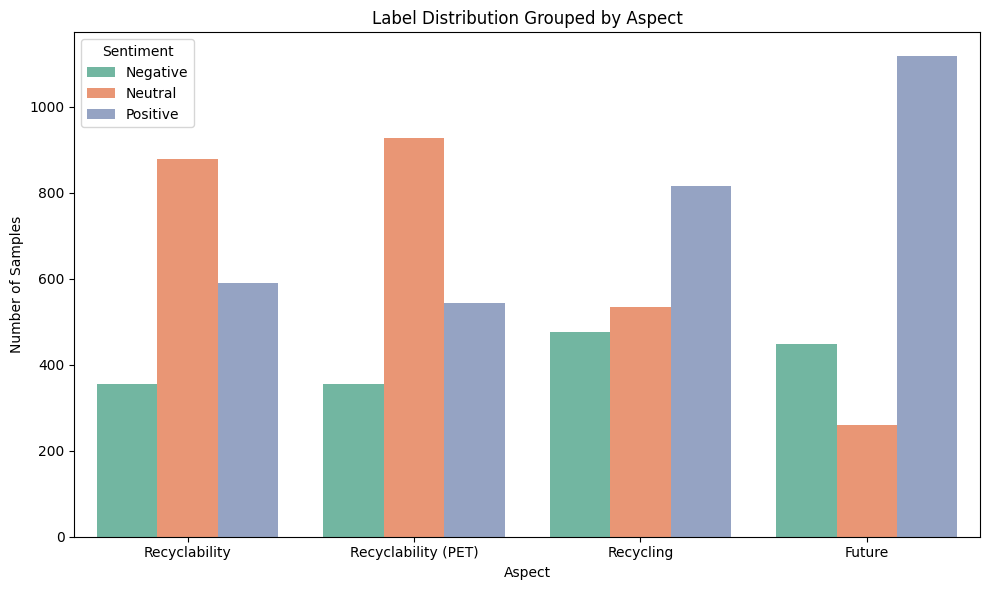

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


label_sums = df_encoded[[
    "Recyclability_Negative",
    "Recyclability_Neutral",
    "Recyclability_Positive",
    "Recyclability (PET)_Negative",
    "Recyclability (PET)_Neutral",
    "Recyclability (PET)_Positive",
    "Recycling_Negative",
    "Recycling_Neutral",
    "Recycling_Positive",
    "Future_Negative",
    "Future_Neutral",
    "Future_Positive"
]].sum()

label_df = label_sums.reset_index()
label_df.columns = ['label', 'count']
label_df['aspect'] = label_df['label'].apply(lambda x: x.split('_')[0])
label_df['sentiment'] = label_df['label'].apply(lambda x: x.split('_')[1])

plt.figure(figsize=(10, 6))
sns.barplot(data=label_df, x='aspect', y='count', hue='sentiment', palette='Set2')
plt.title("Label Distribution Grouped by Aspect")
plt.ylabel("Number of Samples")
plt.xlabel("Aspect")
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()


In [20]:
from sklearn.utils import resample
import pandas as pd

minority_labels = [
    "Future_Neutral",
    "Recyclability (PET)_Negative",
    "Recyclability_Negative"
]

target_count = 600

oversampled_rows = []


for label in minority_labels:
    label_positive = df_encoded[df_encoded[label] == 1]
    if len(label_positive) < target_count:
        label_upsampled = resample(
            label_positive,
            replace=True,
            n_samples=target_count - len(label_positive),
            random_state=42
        )
        oversampled_rows.append(label_upsampled)


df_balanced = pd.concat([df_encoded] + oversampled_rows)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("New shape:", df_balanced.shape)

New shape: (2655, 13)


In [21]:
label_sums = df_balanced[[
    "Recyclability_Negative",
    "Recyclability_Neutral",
    "Recyclability_Positive",
    "Recyclability (PET)_Negative",
    "Recyclability (PET)_Neutral",
    "Recyclability (PET)_Positive",
    "Recycling_Negative",
    "Recycling_Neutral",
    "Recycling_Positive",
    "Future_Negative",
    "Future_Neutral",
    "Future_Positive"
]].sum()


label_df = label_sums.reset_index()
label_df.columns = ['label', 'count']
label_df['aspect'] = label_df['label'].apply(lambda x: x.split('_')[0])
label_df['sentiment'] = label_df['label'].apply(lambda x: x.split('_')[1])


print(label_df)


                           label  count               aspect sentiment
0         Recyclability_Negative    843        Recyclability  Negative
1          Recyclability_Neutral   1074        Recyclability   Neutral
2         Recyclability_Positive    738        Recyclability  Positive
3   Recyclability (PET)_Negative    745  Recyclability (PET)  Negative
4    Recyclability (PET)_Neutral   1350  Recyclability (PET)   Neutral
5   Recyclability (PET)_Positive    560  Recyclability (PET)  Positive
6             Recycling_Negative   1004            Recycling  Negative
7              Recycling_Neutral    696            Recycling   Neutral
8             Recycling_Positive    955            Recycling  Positive
9                Future_Negative    863               Future  Negative
10                Future_Neutral    658               Future   Neutral
11               Future_Positive   1134               Future  Positive


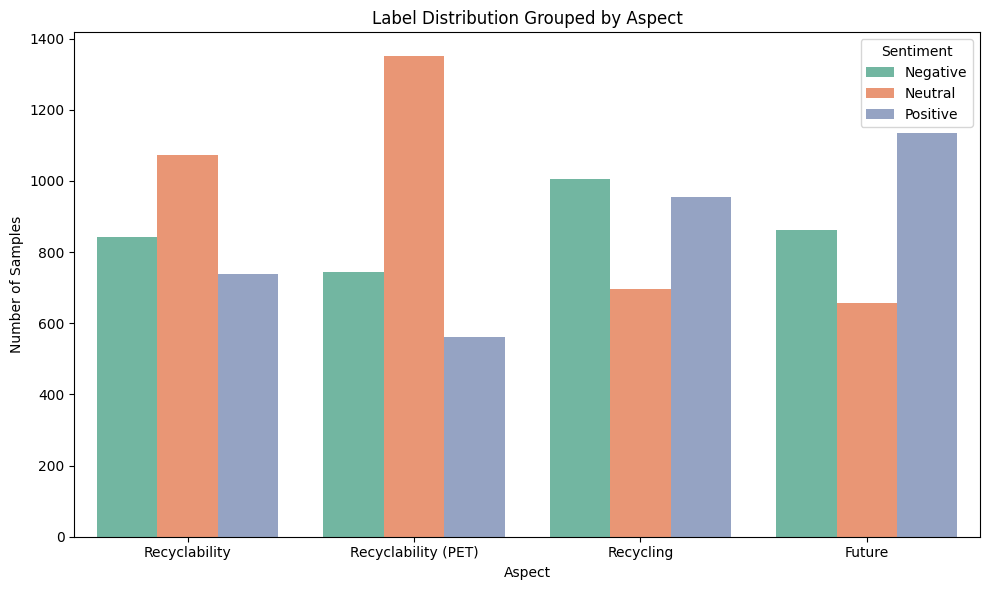

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
label_sums = df_balanced[[
    "Recyclability_Negative",
    "Recyclability_Neutral",
    "Recyclability_Positive",
    "Recyclability (PET)_Negative",
    "Recyclability (PET)_Neutral",
    "Recyclability (PET)_Positive",
    "Recycling_Negative",
    "Recycling_Neutral",
    "Recycling_Positive",
    "Future_Negative",
    "Future_Neutral",
    "Future_Positive"
]].sum()

label_df = label_sums.reset_index()
label_df.columns = ['label', 'count']
label_df['aspect'] = label_df['label'].apply(lambda x: x.split('_')[0])
label_df['sentiment'] = label_df['label'].apply(lambda x: x.split('_')[1])

plt.figure(figsize=(10, 6))
sns.barplot(data=label_df, x='aspect', y='count', hue='sentiment', palette='Set2')
plt.title("Label Distribution Grouped by Aspect")
plt.ylabel("Number of Samples")
plt.xlabel("Aspect")
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()


In [23]:
from sklearn.model_selection import train_test_split

df_encoded = df_balanced.copy()
# If you want to use the original unbalanced dataset, comment out the above line

#For unbalanced dataset, run without copying the balanced dataset
y_recycle = df_encoded[[ 
    "Recycling_Negative", "Recycling_Neutral", "Recycling_Positive"
]]
y_pet = df_encoded[[ 
    "Recyclability (PET)_Negative", "Recyclability (PET)_Neutral", "Recyclability (PET)_Positive"
]]
y_process = df_encoded[[ 
    "Recyclability_Negative", "Recyclability_Neutral", "Recyclability_Positive"
]]
y_effective = df_encoded[[ 
    "Future_Negative", "Future_Neutral", "Future_Positive"
]]

X = df_encoded["text"] 
X_train, X_test, y_recycle_train, y_recycle_test, y_pet_train, y_pet_test, \
y_process_train, y_process_test, y_effective_train, y_effective_test = train_test_split(
    X, y_recycle, y_pet, y_process, y_effective, test_size=0.4, random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))


Train size: 1593
Test size: 1062


In [24]:
from sklearn.model_selection import train_test_split

df_encoded = df_balanced.copy()


target_columns = [
    "Recycling_Negative", "Recycling_Neutral", "Recycling_Positive",
    "Recyclability (PET)_Negative", "Recyclability (PET)_Neutral", "Recyclability (PET)_Positive",
    "Recyclability_Negative", "Recyclability_Neutral", "Recyclability_Positive",
    "Future_Negative", "Future_Neutral", "Future_Positive"
]

X = df_encoded["text"].values  
y = df_encoded[target_columns].values 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

In [68]:
y

array([[1, 0, 0, ..., 1, 0, 0],
       [0, 0, 1, ..., 0, 0, 1],
       [1, 0, 0, ..., 1, 0, 0],
       ...,
       [0, 0, 1, ..., 0, 0, 1],
       [0, 0, 1, ..., 0, 0, 1],
       [1, 0, 0, ..., 1, 0, 0]])

In [25]:
#Feature Extraction
# Using Keras Tokenizer for text preprocessing
# and padding sequences to a fixed length as input for the model

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 10000 
max_len = 100  

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')


In [27]:
import joblib

joblib.dump(tokenizer, 'tokenizer_from_final.pkl')

['tokenizer_from_final.pkl']

In [28]:
tokenizer.word_index["plastik"]

2

In [29]:
X_test[5]

'indonesia masih berjuang untuk melepaskan diri dari ketergantungan terhadap sampah impor yang telah menjadi hal yang sangat penting bagi industri daur ulang terutama dalam produksi kertas dan plastik.'

In [30]:
X_test_seq[5]

[17,
 19,
 2673,
 9,
 2163,
 517,
 11,
 1126,
 189,
 4,
 324,
 7,
 171,
 16,
 142,
 7,
 69,
 252,
 152,
 71,
 5,
 3,
 254,
 29,
 127,
 134,
 8,
 2]

In [32]:
#FEED FORWARD NEURAL NETWORK
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 100

early_stop = EarlyStopping(monitor='val_loss',
                        patience=3,
                        restore_best_weights=True)


model_FNN = Sequential([
    Input(shape=(max_len,), name='text_input'),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(12, activation='sigmoid')
])



model_FNN.compile(optimizer=Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy', 'precision', 'recall'])

model_FNN.summary()

# Train
history_FFN = model_FNN.fit(X_train_pad, y_train, epochs=30, 
                    batch_size=32, validation_split=0.2,
                    callbacks=[early_stop])


c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │       970,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 100)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 977,544 (3.73 MB)

 Trainable params: 977,544 (3.73 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.0321 - loss: 0.6718 - precision: 0.3587 - recall: 0.2786 - val_accuracy: 0.0047 - val_loss: 0.6247 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0459 - loss: 0.6389 - precision: 0.4402 - recall: 0.1002 - val_accuracy: 0.0000e+00 - val_loss: 0.6212 - val_precision: 0.8095 - val_recall: 0.0100
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0473 - loss: 0.6333 - precision: 0.4527 - recall: 0.0994 - val_accuracy: 0.0000e+00 - val_loss: 0.6176 - val_precision: 0.6633 - val_recall: 0.0776
Epoch 4/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0238 - loss: 0.6248 - precision: 0.5209 - recall: 0.1186 - val_accuracy: 0.0000e+00 - val_loss: 0.6139 - val_precision: 0.7117 - val_recall: 0.0682
Epoch 5/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0352 - loss: 0.6192 - precision: 0.5367 - recall: 0.1310 - val_accuracy: 0.0000e+00

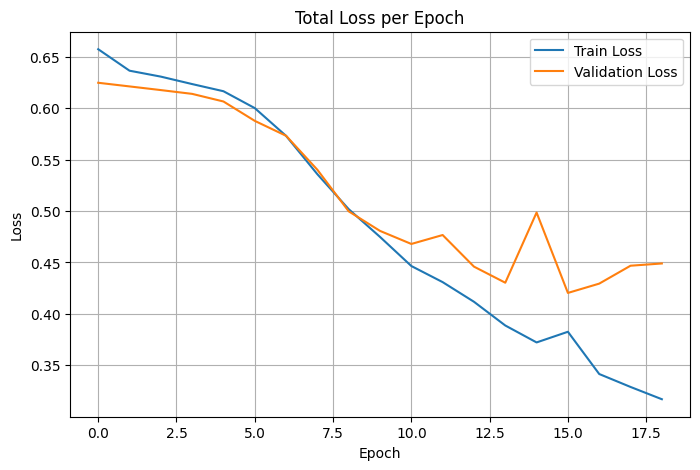

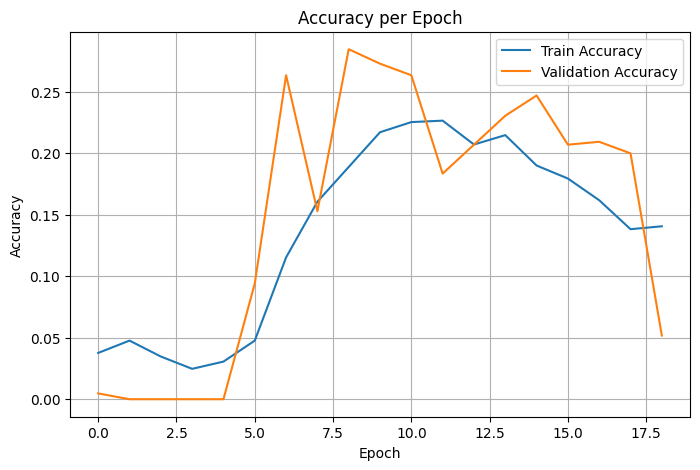

In [33]:
import matplotlib.pyplot as plt

# Total Loss plot
plt.figure(figsize=(8, 5))
plt.plot(history_FFN.history['loss'], label='Train Loss')
plt.plot(history_FFN.history['val_loss'], label='Validation Loss')
plt.title('Total Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Binary Accuracy plot (more meaningful for multi-label)
plt.figure(figsize=(8, 5))
plt.plot(history_FFN.history['accuracy'], label='Train Accuracy')
plt.plot(history_FFN.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Overall Binary Accuracy (per label, averaged): 0.7987


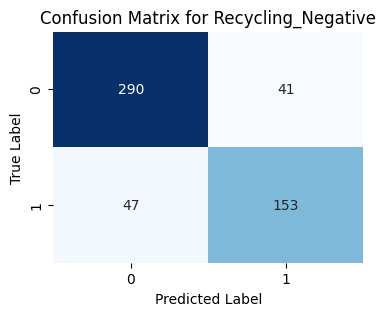

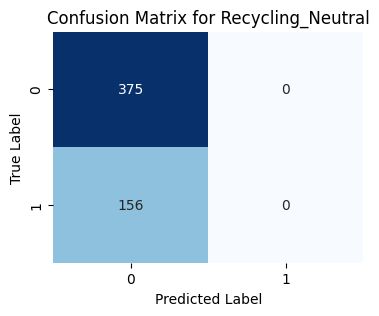

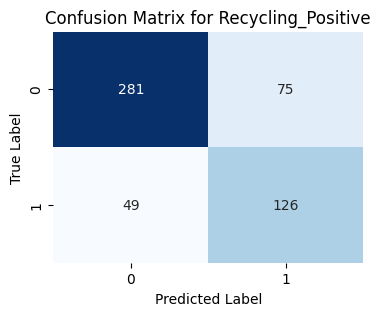

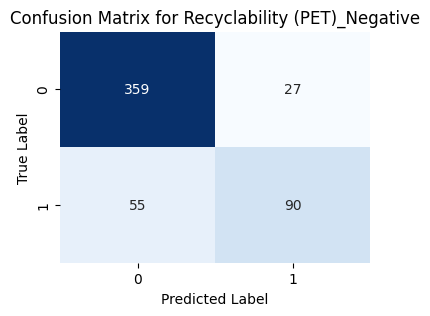

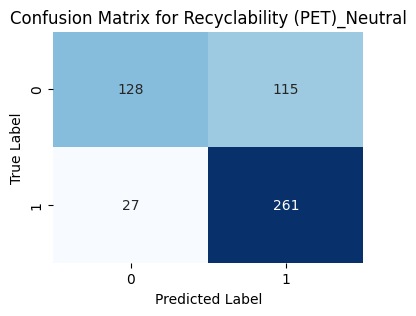

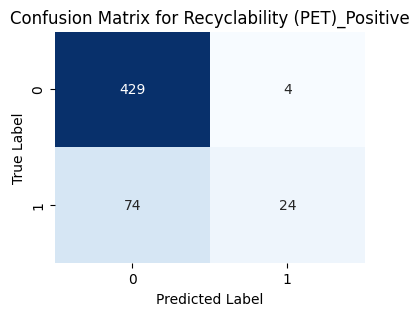

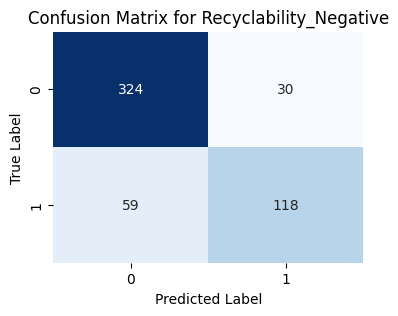

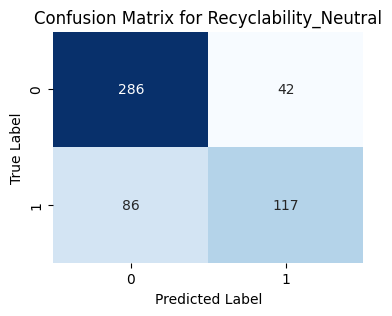

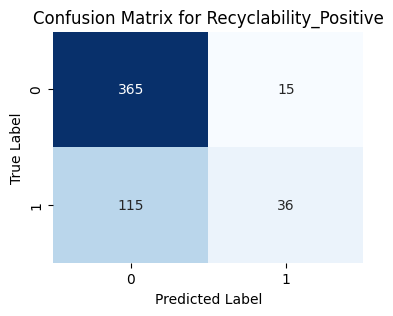

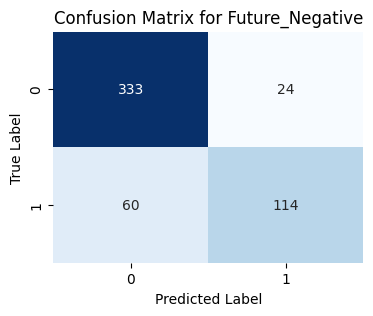

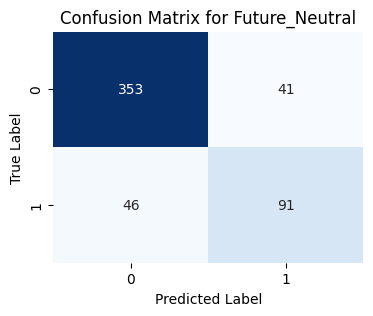

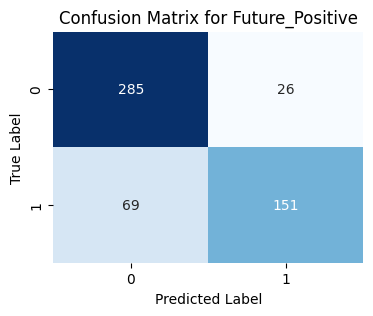

Micro F1-score: 0.6663
Micro Precision: 0.7443
Micro Recall: 0.6031


In [34]:
#EVAL FFN
from sklearn.metrics import multilabel_confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score


# Predict probabilities
y_pred = model_FNN.predict(X_test_pad)
y_pred_binary = (y_pred > 0.5).astype(int)
total_binary_accuracy = (y_pred_binary == y_test).mean()
print(f"Overall Binary Accuracy (per label, averaged): {total_binary_accuracy:.4f}")


# y_test: True binary labels, shape (num_samples, num_labels)
# y_pred: Model's raw probabilities, same shape

# Convert probabilities to binary predictions with threshold
y_pred_binary = (y_pred > 0.5).astype(int)

# Get confusion matrix for each label
cm = multilabel_confusion_matrix(y_test, y_pred_binary)

label_names = [
    "Recycling_Negative", "Recycling_Neutral", "Recycling_Positive",
    "Recyclability (PET)_Negative", "Recyclability (PET)_Neutral", "Recyclability (PET)_Positive",
    "Recyclability_Negative", "Recyclability_Neutral", "Recyclability_Positive",
    "Future_Negative", "Future_Neutral", "Future_Positive"
]

# Plot confusion matrix for each label
for idx, matrix in enumerate(cm):
    plt.figure(figsize=(4, 3))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Confusion Matrix for {label_names[idx]}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


# Micro average: Global metrics across all labels and samples
f1 = f1_score(y_test, y_pred_binary, average='micro')
precision = precision_score(y_test, y_pred_binary, average='micro')
recall = recall_score(y_test, y_pred_binary, average='micro')

print(f"Micro F1-score: {f1:.4f}")
print(f"Micro Precision: {precision:.4f}")
print(f"Micro Recall: {recall:.4f}")


In [35]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score


# Precision per label
precision_per_label = precision_score(y_test, y_pred_binary, average=None)

# Recall per label
recall_per_label = recall_score(y_test, y_pred_binary, average=None)

# F1-score per label
f1_per_label = f1_score(y_test, y_pred_binary, average=None)

# Tampilkan hasil
for idx, (p, r, f) in enumerate(zip(precision_per_label, recall_per_label, f1_per_label)):
    print(f"Label {label_names[idx]}: Precision = {p:.4f}, Recall = {r:.4f}, F1-score = {f:.4f}")

# Akurasi per label
accuracy_per_label = [accuracy_score(y_test[:, i], y_pred_binary[:, i]) for i in range(y_test.shape[1])]

# Tampilkan hasil
for idx, acc in enumerate(accuracy_per_label):
    print(f"Label {label_names[idx]}: Accuracy = {acc:.4f}")



Label Recycling_Negative: Precision = 0.7887, Recall = 0.7650, F1-score = 0.7766
Label Recycling_Neutral: Precision = 0.0000, Recall = 0.0000, F1-score = 0.0000
Label Recycling_Positive: Precision = 0.6269, Recall = 0.7200, F1-score = 0.6702
Label Recyclability (PET)_Negative: Precision = 0.7692, Recall = 0.6207, F1-score = 0.6870
Label Recyclability (PET)_Neutral: Precision = 0.6941, Recall = 0.9062, F1-score = 0.7861
Label Recyclability (PET)_Positive: Precision = 0.8571, Recall = 0.2449, F1-score = 0.3810
Label Recyclability_Negative: Precision = 0.7973, Recall = 0.6667, F1-score = 0.7262
Label Recyclability_Neutral: Precision = 0.7358, Recall = 0.5764, F1-score = 0.6464
Label Recyclability_Positive: Precision = 0.7059, Recall = 0.2384, F1-score = 0.3564
Label Future_Negative: Precision = 0.8261, Recall = 0.6552, F1-score = 0.7308
Label Future_Neutral: Precision = 0.6894, Recall = 0.6642, F1-score = 0.6766
Label Future_Positive: Precision = 0.8531, Recall = 0.6864, F1-score = 0.7607

c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [52]:
#LSTM

from tensorflow.keras.layers import Input, Dense, Dropout, Embedding, GlobalMaxPooling1D,LSTM, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 100


early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


inputs = Input(shape=(max_len,), name='text_input')
x = Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
              input_length=max_len)(inputs)
x = LSTM(64, return_sequences=True)(x)
x = GlobalMaxPooling1D()(x)
x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
output = Dense(12, activation='sigmoid', name='multi_label_output')(x)
model = Model(inputs=inputs, outputs=output)

# Compile with binary crossentropy loss for multi-label
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy', 'precision', 'recall'])


model.summary()

history = model.fit(X_train_pad, y_train, epochs=30, batch_size=32, validation_split=0.2,callbacks=[early_stop])



c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_input (InputLayer)         │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_4 (Embedding)         │ (None, 100, 100)       │       970,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100, 64)        │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multi_label_output (Dense)      │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,017,736 (3.88 MB)

 Trainable params: 1,017,608 (3.88 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.1037 - loss: 0.6828 - precision: 0.3720 - recall: 0.4798 - val_accuracy: 0.0965 - val_loss: 0.6592 - val_precision: 0.9792 - val_recall: 0.0276
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.1622 - loss: 0.5313 - precision: 0.6209 - recall: 0.6964 - val_accuracy: 0.1176 - val_loss: 0.6098 - val_precision: 0.7885 - val_recall: 0.1206
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.1577 - loss: 0.3887 - precision: 0.7480 - recall: 0.7827 - val_accuracy: 0.2000 - val_loss: 0.5687 - val_precision: 0.9505 - val_recall: 0.1129
Epoch 4/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.1789 - loss: 0.2905 - precision: 0.8307 - recall: 0.8426 - val_accuracy: 0.1671 - val_loss: 0.5372 - val_precision: 0.8687 - val_recall: 0.1712
Epoch 5/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.2069 - loss: 0.2241 - precision: 0.8841 - recall: 0.8732 - val_accuracy: 0.2212 - val_loss: 0.4947 

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
Overall Binary Accuracy (per label, averaged): 0.8534


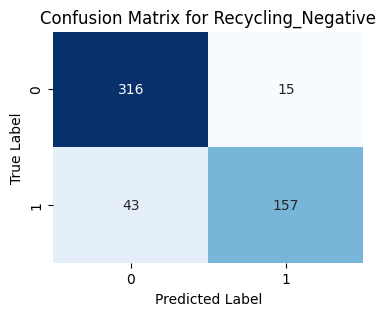

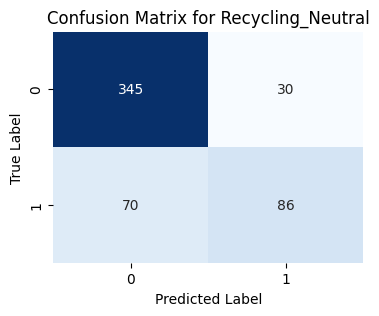

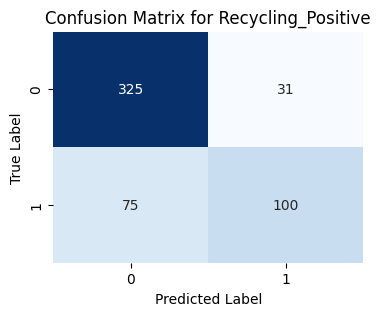

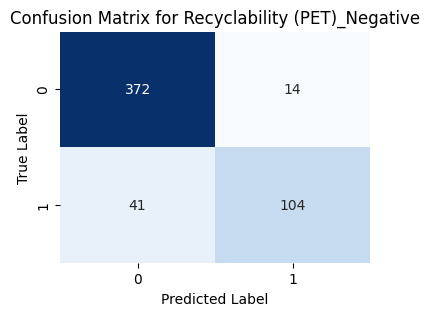

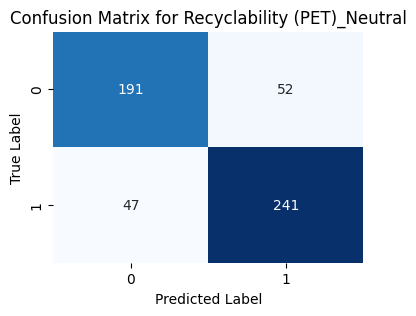

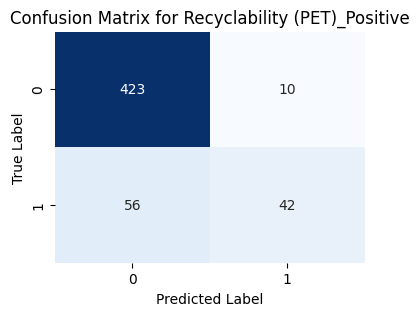

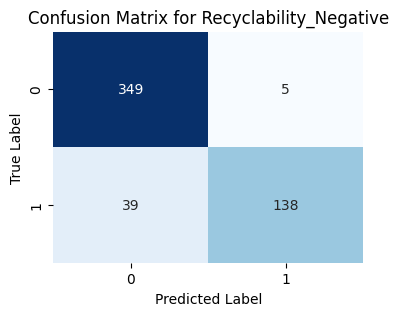

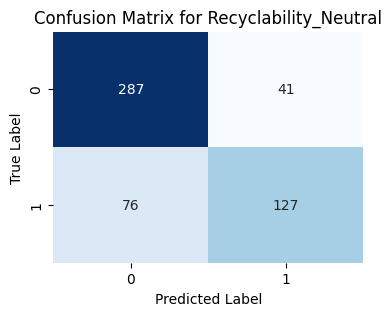

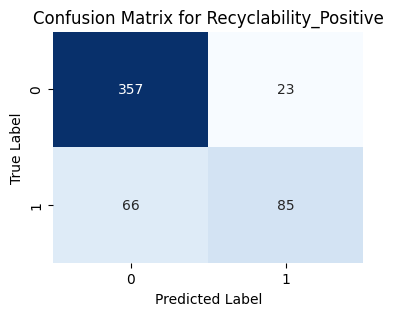

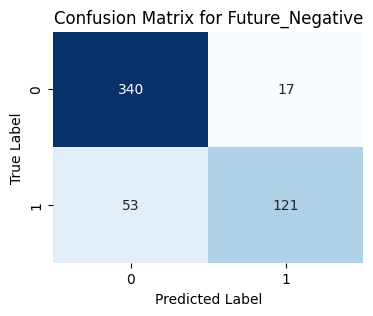

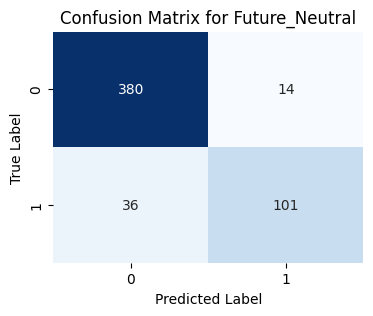

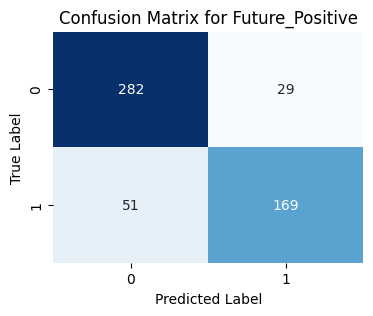

Micro F1-score: 0.7590
Micro Precision: 0.8396
Micro Recall: 0.6926


In [53]:
#EVAL LSTM
from sklearn.metrics import multilabel_confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score


# Predict probabilities
y_pred = model.predict(X_test_pad)

# Convert to binary predictions with threshold 0.5
y_pred_binary = (y_pred > 0.5).astype(int)

total_binary_accuracy = (y_pred_binary == y_test).mean()
print(f"Overall Binary Accuracy (per label, averaged): {total_binary_accuracy:.4f}")

y_pred_binary = (y_pred > 0.5).astype(int)

# Get confusion matrix for each label
cm = multilabel_confusion_matrix(y_test, y_pred_binary)

# Optional: Label names (update to your specific label structure)
label_names = [
    "Recycling_Negative", "Recycling_Neutral", "Recycling_Positive",
    "Recyclability (PET)_Negative", "Recyclability (PET)_Neutral", "Recyclability (PET)_Positive",
    "Recyclability_Negative", "Recyclability_Neutral", "Recyclability_Positive",
    "Future_Negative", "Future_Neutral", "Future_Positive"
]

# Plot confusion matrix for each label
for idx, matrix in enumerate(cm):
    plt.figure(figsize=(4, 3))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Confusion Matrix for {label_names[idx]}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


# Micro average: Global metrics across all labels and samples
f1 = f1_score(y_test, y_pred_binary, average='micro')
precision = precision_score(y_test, y_pred_binary, average='micro')
recall = recall_score(y_test, y_pred_binary, average='micro')

print(f"Micro F1-score: {f1:.4f}")
print(f"Micro Precision: {precision:.4f}")
print(f"Micro Recall: {recall:.4f}")


In [54]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score


# Precision per label
precision_per_label = precision_score(y_test, y_pred_binary, average=None)

# Recall per label
recall_per_label = recall_score(y_test, y_pred_binary, average=None)

# F1-score per label
f1_per_label = f1_score(y_test, y_pred_binary, average=None)

# Tampilkan hasil
for idx, (p, r, f) in enumerate(zip(precision_per_label, recall_per_label, f1_per_label)):
    print(f"Label {label_names[idx]}: Precision = {p:.4f}, Recall = {r:.4f}, F1-score = {f:.4f}")

# Akurasi per label
accuracy_per_label = [accuracy_score(y_test[:, i], y_pred_binary[:, i]) for i in range(y_test.shape[1])]

# Tampilkan hasil
for idx, acc in enumerate(accuracy_per_label):
    print(f"Label {label_names[idx]}: Accuracy = {acc:.4f}")



Label Recycling_Negative: Precision = 0.9128, Recall = 0.7850, F1-score = 0.8441
Label Recycling_Neutral: Precision = 0.7414, Recall = 0.5513, F1-score = 0.6324
Label Recycling_Positive: Precision = 0.7634, Recall = 0.5714, F1-score = 0.6536
Label Recyclability (PET)_Negative: Precision = 0.8814, Recall = 0.7172, F1-score = 0.7909
Label Recyclability (PET)_Neutral: Precision = 0.8225, Recall = 0.8368, F1-score = 0.8296
Label Recyclability (PET)_Positive: Precision = 0.8077, Recall = 0.4286, F1-score = 0.5600
Label Recyclability_Negative: Precision = 0.9650, Recall = 0.7797, F1-score = 0.8625
Label Recyclability_Neutral: Precision = 0.7560, Recall = 0.6256, F1-score = 0.6846
Label Recyclability_Positive: Precision = 0.7870, Recall = 0.5629, F1-score = 0.6564
Label Future_Negative: Precision = 0.8768, Recall = 0.6954, F1-score = 0.7756
Label Future_Neutral: Precision = 0.8783, Recall = 0.7372, F1-score = 0.8016
Label Future_Positive: Precision = 0.8535, Recall = 0.7682, F1-score = 0.8086

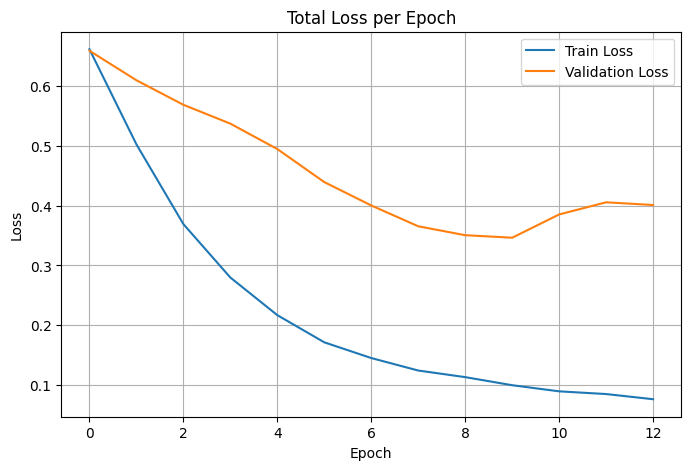

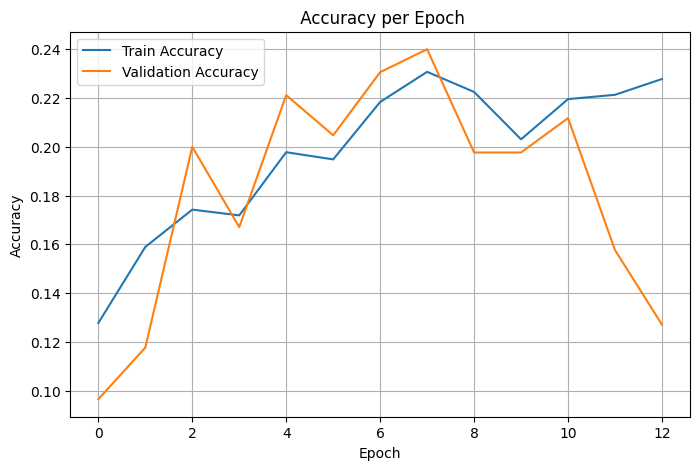

In [55]:
import matplotlib.pyplot as plt

# Total Loss plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Total Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Binary Accuracy plot (more meaningful for multi-label)
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title(' Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [63]:
#BILSTM

from tensorflow.keras.layers import Input, Dense, Dropout, Embedding, Bidirectional,LSTM
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Bidirectional,BatchNormalization,GlobalMaxPooling1D

vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 100


early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


inputs = Input(shape=(max_len,), name='input_text')
x = Embedding(input_dim=vocab_size, output_dim=embedding_dim,
              input_length=max_len)(inputs)
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = GlobalMaxPooling1D()(x)
x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
output = Dense(12, activation='sigmoid', name='multi_label_output')(x)
bimodel = Model(inputs=inputs, outputs=output)

# Compile with binary crossentropy loss for multi-label
bimodel.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy', 'precision', 'recall'])


bimodel.summary()

bihistory = bimodel.fit(X_train_pad, y_train, epochs=30, batch_size=32, validation_split=0.2,callbacks=[early_stop])



c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_text (InputLayer)         │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_6 (Embedding)         │ (None, 100, 100)       │       970,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 100, 128)       │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_4          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multi_label_output (Dense)      │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,064,072 (4.06 MB)

 Trainable params: 1,063,944 (4.06 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - accuracy: 0.1338 - loss: 0.6746 - precision: 0.3958 - recall: 0.5115 - val_accuracy: 0.2941 - val_loss: 0.6551 - val_precision: 0.9412 - val_recall: 0.0094
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.2742 - loss: 0.5174 - precision: 0.6338 - recall: 0.6961 - val_accuracy: 0.2212 - val_loss: 0.5996 - val_precision: 1.0000 - val_recall: 0.0276
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.2359 - loss: 0.3623 - precision: 0.7807 - recall: 0.7992 - val_accuracy: 0.2047 - val_loss: 0.5689 - val_precision: 0.9855 - val_recall: 0.0400
Epoch 4/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.2237 - loss: 0.2750 - precision: 0.8562 - recall: 0.8330 - val_accuracy: 0.2329 - val_loss: 0.5338 - val_precision: 0.9873 - val_recall: 0.0912
Epoch 5/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.2467 - loss: 0.2140 - precision: 0.8991 - recall: 0.8775 - val_accuracy: 0.2188 - val_loss: 0.5018 

In [69]:
#save model

model_FNN.save('model_FNN.keras')
model.save('model_LSTM.keras')
bimodel.save('model_BiLSTM.keras')

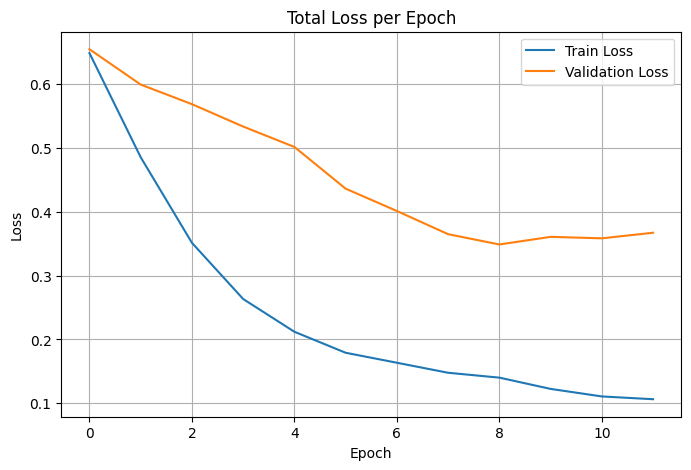

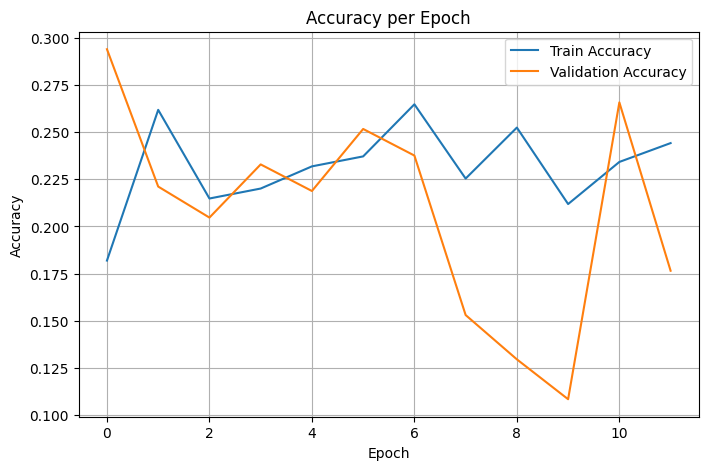

In [64]:
import matplotlib.pyplot as plt

# Total Loss plot
plt.figure(figsize=(8, 5))
plt.plot(bihistory.history['loss'], label='Train Loss')
plt.plot(bihistory.history['val_loss'], label='Validation Loss')
plt.title('Total Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(bihistory.history['accuracy'], label='Train Accuracy')
plt.plot(bihistory.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [65]:

y_pred = bimodel.predict(X_test_pad)
y_pred_binary = (y_pred > 0.5).astype(int)

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step


In [66]:
total_binary_accuracy = (y_pred_binary == y_test).mean()
print(f"Overall Binary Accuracy (per label, averaged): {total_binary_accuracy:.4f}")


Overall Binary Accuracy (per label, averaged): 0.8512


In [67]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score



precision_per_label = precision_score(y_test, y_pred_binary, average=None)
recall_per_label = recall_score(y_test, y_pred_binary, average=None)
f1_per_label = f1_score(y_test, y_pred_binary, average=None)
accuracy_per_label = [accuracy_score(y_test[:, i],
                 y_pred_binary[:, i]) for i in range(y_test.shape[1])]


for idx, (p, r, f) in enumerate(zip(precision_per_label, recall_per_label, f1_per_label)):
    print(f"Label {label_names[idx]}: Precision = {p:.4f}, Recall = {r:.4f}, F1-score = {f:.4f}")

# Akurasi per label

# Tampilkan hasil
for idx, acc in enumerate(accuracy_per_label):
    print(f"Label {label_names[idx]}: Accuracy = {acc:.4f}")



Label Recycling_Negative: Precision = 0.9497, Recall = 0.7550, F1-score = 0.8412
Label Recycling_Neutral: Precision = 0.8594, Recall = 0.3526, F1-score = 0.5000
Label Recycling_Positive: Precision = 0.7102, Recall = 0.7143, F1-score = 0.7123
Label Recyclability (PET)_Negative: Precision = 0.8934, Recall = 0.7517, F1-score = 0.8165
Label Recyclability (PET)_Neutral: Precision = 0.8480, Recall = 0.7361, F1-score = 0.7881
Label Recyclability (PET)_Positive: Precision = 0.9394, Recall = 0.3163, F1-score = 0.4733
Label Recyclability_Negative: Precision = 0.9600, Recall = 0.8136, F1-score = 0.8807
Label Recyclability_Neutral: Precision = 0.7744, Recall = 0.6256, F1-score = 0.6921
Label Recyclability_Positive: Precision = 0.7826, Recall = 0.4768, F1-score = 0.5926
Label Future_Negative: Precision = 0.8726, Recall = 0.7874, F1-score = 0.8278
Label Future_Neutral: Precision = 1.0000, Recall = 0.5109, F1-score = 0.6763
Label Future_Positive: Precision = 0.8387, Recall = 0.8273, F1-score = 0.8330

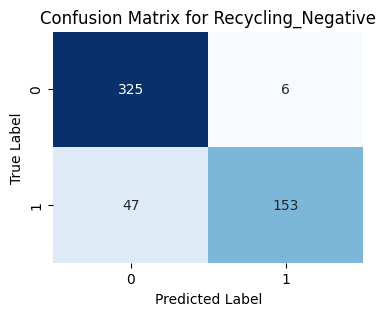

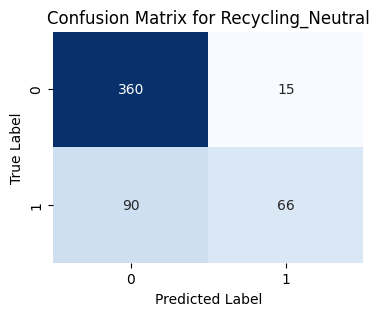

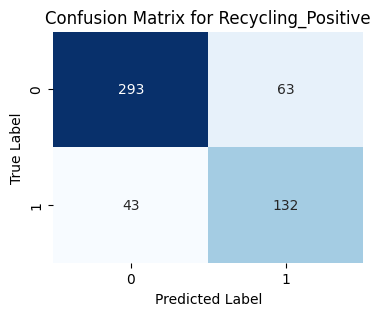

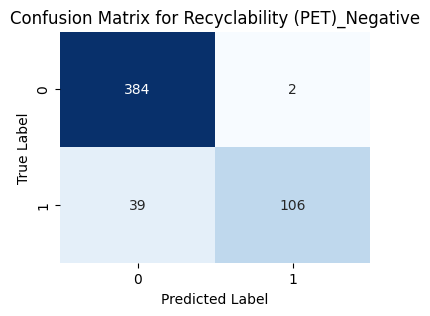

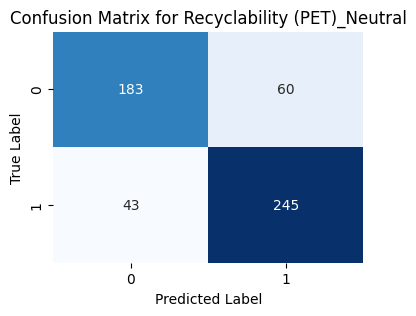

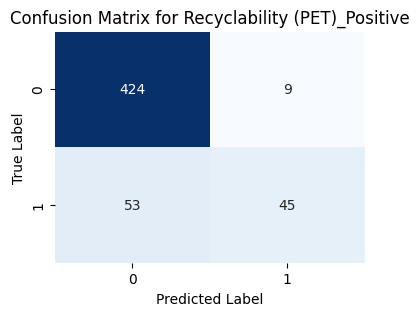

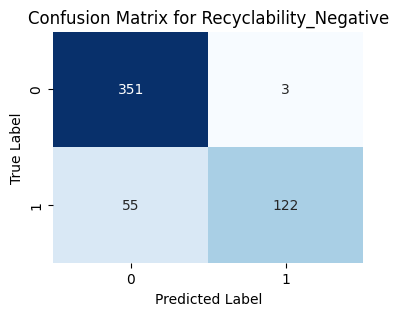

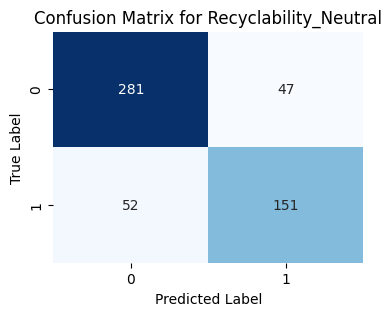

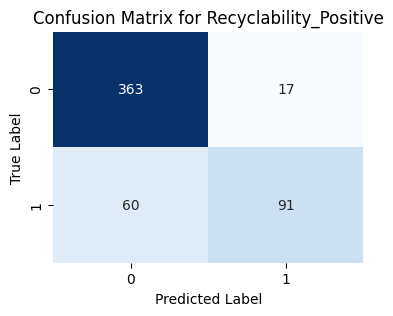

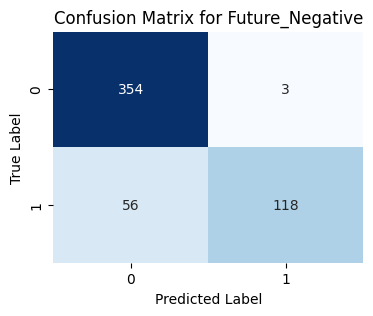

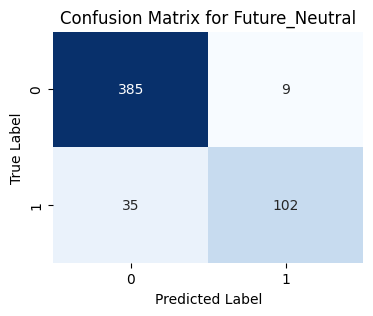

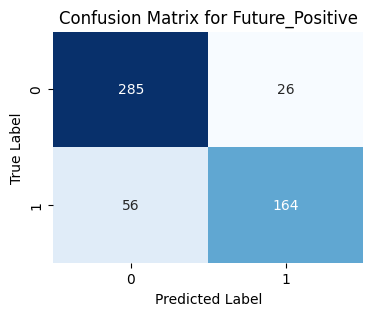

In [46]:
from sklearn.metrics import multilabel_confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


y_pred_binary = (y_pred > 0.5).astype(int)


cm = multilabel_confusion_matrix(y_test, y_pred_binary)

label_names = [
    "Recycling_Negative", "Recycling_Neutral", "Recycling_Positive",
    "Recyclability (PET)_Negative", "Recyclability (PET)_Neutral", "Recyclability (PET)_Positive",
    "Recyclability_Negative", "Recyclability_Neutral", "Recyclability_Positive",
    "Future_Negative", "Future_Neutral", "Future_Positive"
]

# Plot confusion matrix for each label
for idx, matrix in enumerate(cm):
    plt.figure(figsize=(4, 3))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Confusion Matrix for {label_names[idx]}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


In [62]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Micro average: Global metrics across all labels and samples
f1 = f1_score(y_test, y_pred_binary, average='micro')
precision = precision_score(y_test, y_pred_binary, average='micro')
recall = recall_score(y_test, y_pred_binary, average='micro')

print(f"F1-score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")


F1-score: 0.7544
Precision: 0.8615
Recall: 0.6709


In [48]:
print(np.sum(y_pred_binary, axis=0))
print(np.sum(y_test, axis=0))


[159  81 195 108 305  54 125 198 108 121 111 190]
[200 156 175 145 288  98 177 203 151 174 137 220]
